# Matching inference

In [1]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 3, Finished, Available, Finished, False)

In [2]:
%run ./matching_inference

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 4, Finished, Available, Finished, True)

## Load Data 

### Adopt matching result

In [3]:
# Change here !!!
match_method = "summary_4"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)
# df
# df["top3_mean_consumption"] = pd.to_numeric(df["top3_mean_consumption"], errors="coerce")

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 5, Finished, Available, Finished, False)

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 6, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se   t_stat  p_value  \
0          -35        4.7303        4.7986 -0.0683 0.2360  -0.2894   0.7723   
1          -34        4.7393        4.9201 -0.1808 0.1646  -1.0984   0.2720   
2          -33        4.7656        5.0121 -0.2465 0.1589  -1.5509   0.1209   
3          -32        4.8386        5.1592 -0.3206 0.1879  -1.7061   0.0880   
4          -31        4.7643        4.7662 -0.0020 0.2474  -0.0080   0.9936   
5          -30        4.7971        4.6750  0.1221 0.2498   0.4889   0.6249   
6          -29        4.4810        4.8278 -0.3467 0.1823  -1.9017   0.0572   
7          -28        4.4976        4.8301 -0.3325 0.1502  -2.2140   0.0268   
8          -27        4.4471        4.7632 -0.3161 0.1091  -2.8971   0.0038   
9          -26        4.5971        5.0484 -0.4513 0.0789  -5.7190   0.0000   
10         -25        4.7440        5.1710 -0.4270 0.0834  -5.1194   0.0000   


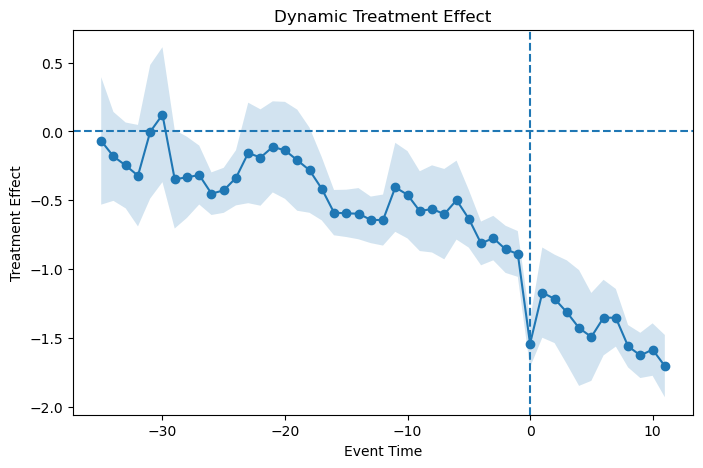


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': -0.6424026869569063, 't_stat': -14.069984518038751, 'p_value': 2.2312638381108475e-08}

===== OVERALL ATT =====
{'ATT': -1.4438243244133009, 'SE': 0.04820411945193136, 't_stat': -29.952301604701386, 'p_value': 0.0, 'CI_low': -1.5383043985390863, 'CI_high': -1.3493442502875155, 'n_periods': 12}

===== COHORT DYNAMIC EFFECT =====


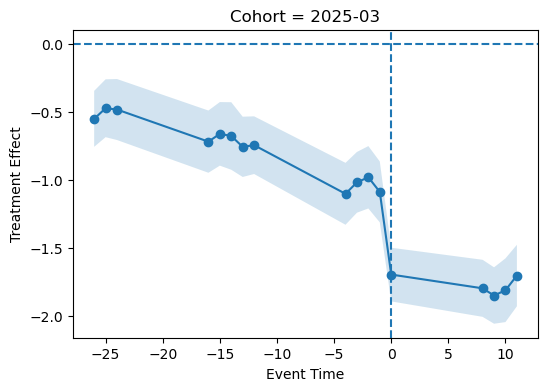

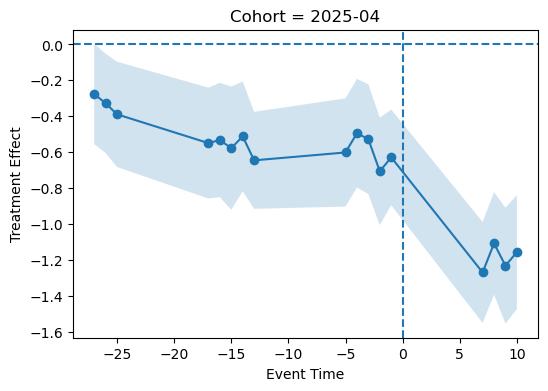

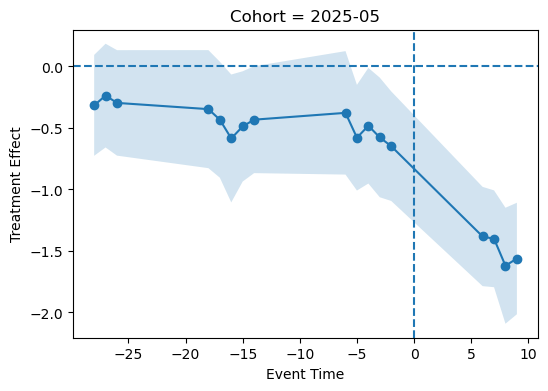

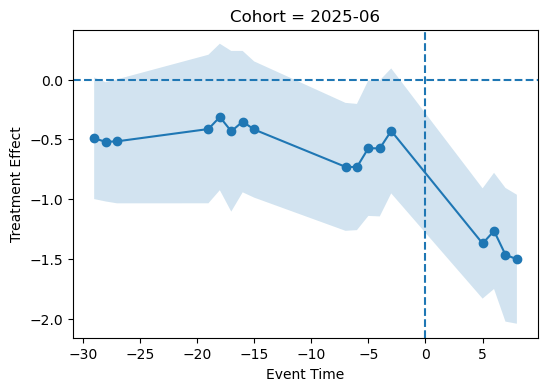

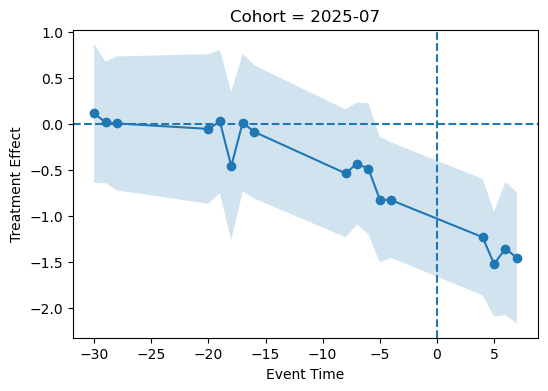

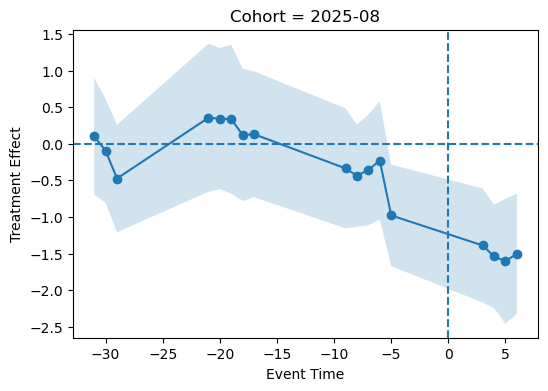

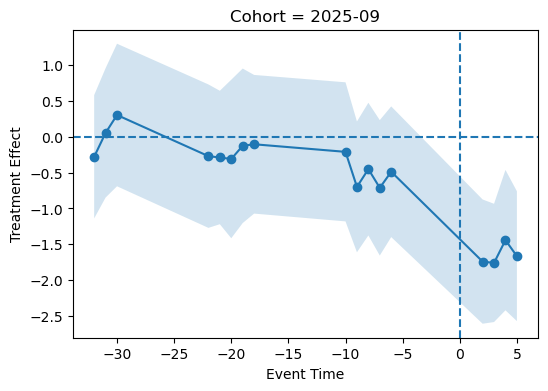

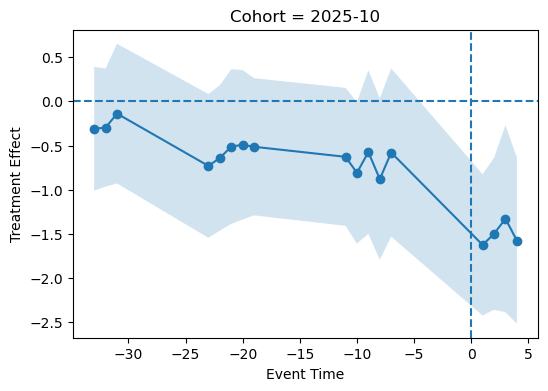

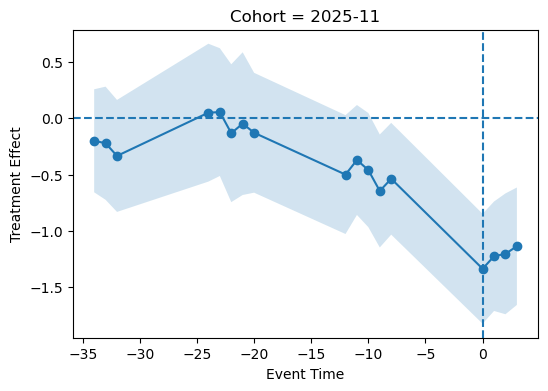

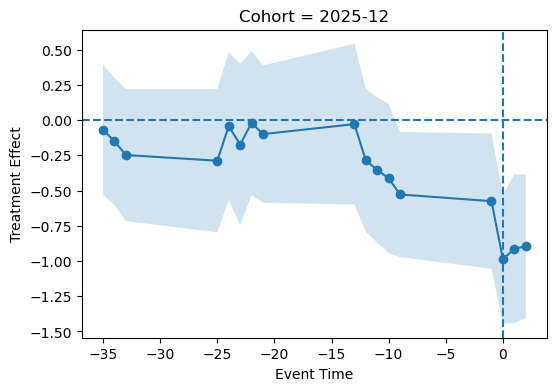

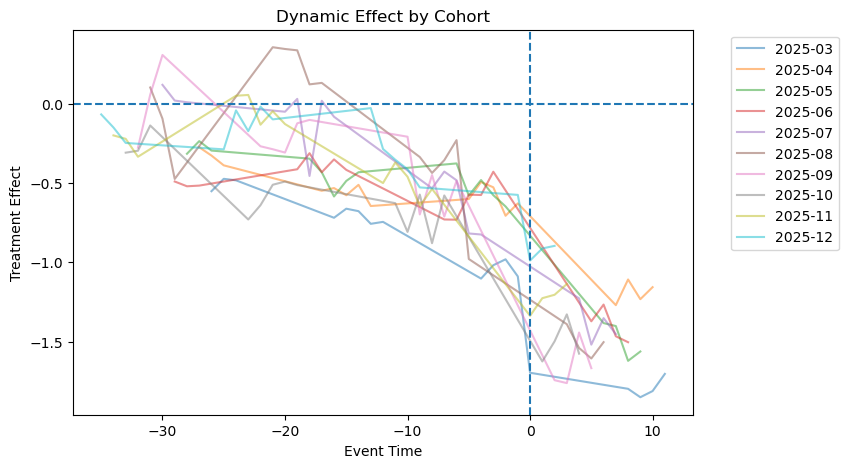


===== ATT BY COHORT =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -1.7711 0.0306 -57.8153   0.0000 -1.8312  -1.7111          5
1  2025-04 -1.1915 0.0365 -32.6465   0.0000 -1.2631  -1.1200          4
2  2025-05 -1.4915 0.0588 -25.3560   0.0000 -1.6068  -1.3762          4
3  2025-06 -1.4015 0.0530 -26.4446   0.0000 -1.5054  -1.2977          4
4  2025-07 -1.3872 0.0634 -21.8702   0.0000 -1.5115  -1.2629          4
5  2025-08 -1.5094 0.0452 -33.3749   0.0000 -1.5980  -1.4207          4
6  2025-09 -1.6530 0.0731 -22.5978   0.0000 -1.7963  -1.5096          4
7  2025-10 -1.5063 0.0649 -23.2140   0.0000 -1.6334  -1.3791          4
8  2025-11 -1.2260 0.0416 -29.4691   0.0000 -1.3075  -1.1444          4
9  2025-12 -0.9325 0.0285 -32.7488   0.0000 -0.9883  -0.8767          3
✅ Results saved to: /lakehouse/default/Files/output/inference/matching/summary_4_high


In [4]:
df_high = df[df["price"]== "high"] 
results_high = run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching/{match_method}_high")

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 7, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.4359        5.6639 -0.2279 0.2713 -0.8402   0.4008   
1          -34        5.8549        5.8823 -0.0274 0.2146 -0.1278   0.8983   
2          -33        5.9161        5.9061  0.0100 0.2021  0.0496   0.9604   
3          -32        5.6449        5.7440 -0.0990 0.1910 -0.5184   0.6042   
4          -31        5.3000        5.2815  0.0185 0.1787  0.1037   0.9174   
5          -30        5.0478        5.0602 -0.0123 0.1634 -0.0755   0.9398   
6          -29        5.1316        5.1249  0.0067 0.1532  0.0440   0.9649   
7          -28        5.0651        5.1599 -0.0948 0.1301 -0.7288   0.4661   
8          -27        5.2364        5.3105 -0.0741 0.1082 -0.6848   0.4935   
9          -26        5.7963        5.7625  0.0338 0.0890  0.3793   0.7045   
10         -25        5.9034        5.8223  0.0811 0.0924  0.8780   0.3799   
11         -

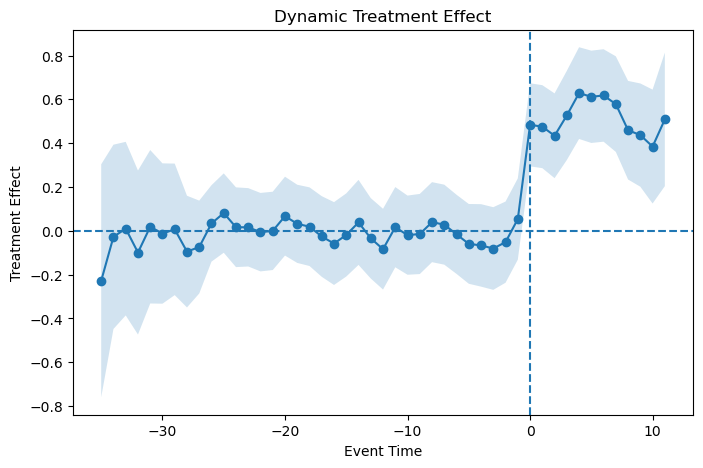


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': -0.021209667303363194, 't_stat': -1.5358379571975003, 'p_value': 0.15282694248864254}

===== OVERALL ATT =====
{'ATT': 0.5122179404259725, 'SE': 0.02340272599208701, 't_stat': 21.887105826866705, 'p_value': 0.0, 'CI_low': 0.46634859748148194, 'CI_high': 0.558087283370463, 'n_periods': 12}

===== COHORT DYNAMIC EFFECT =====


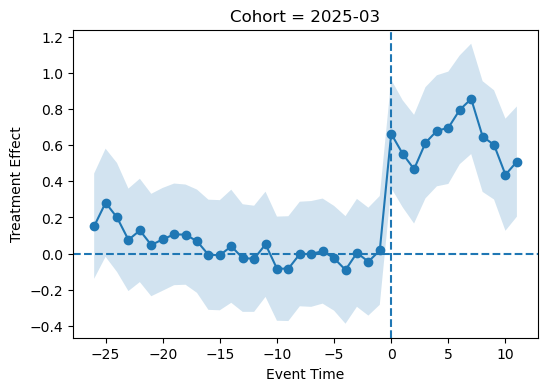

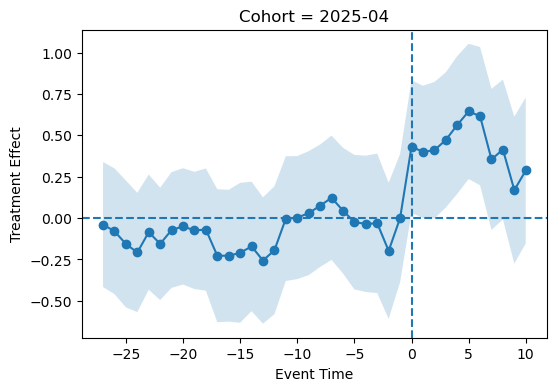

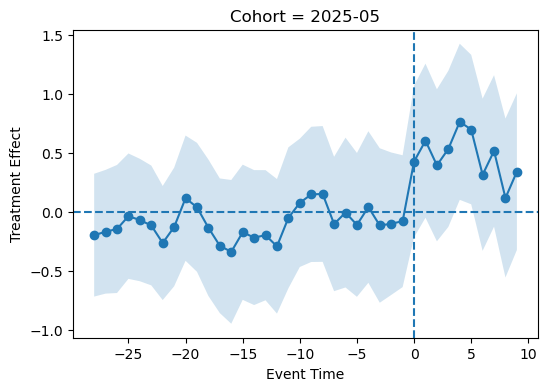

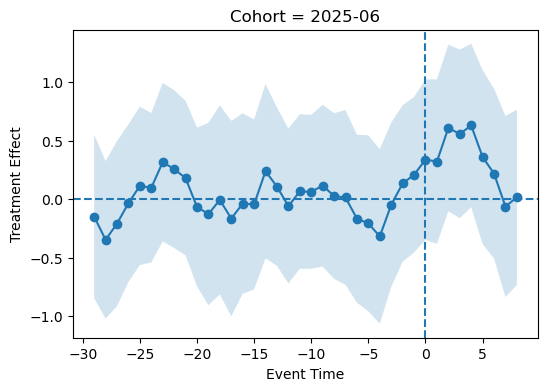

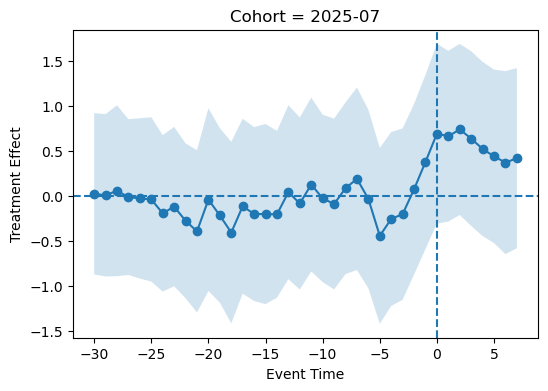

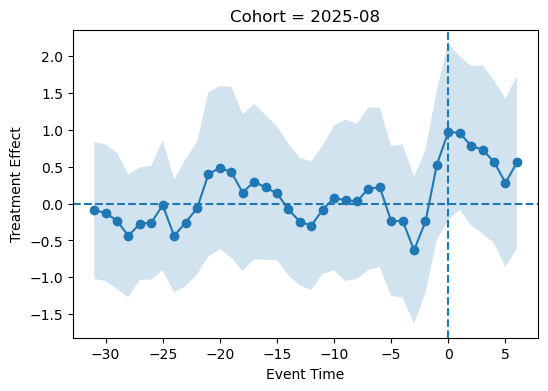

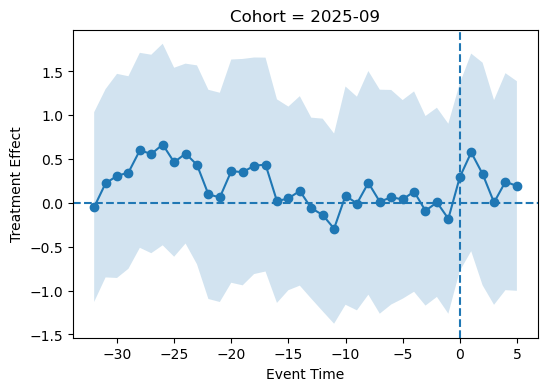

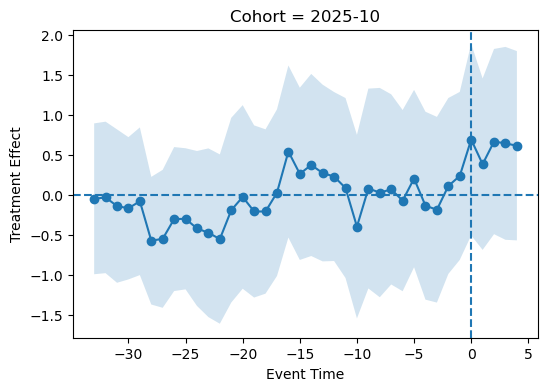

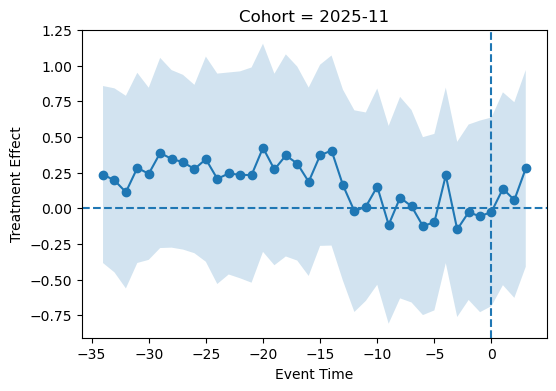

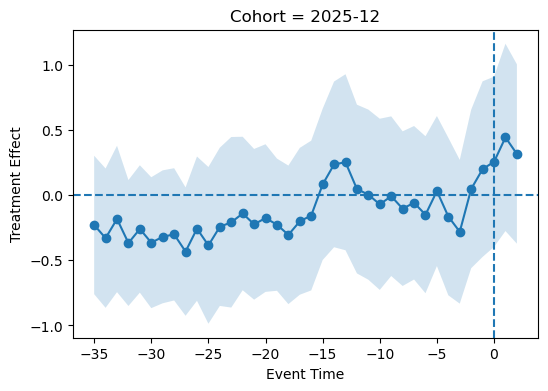

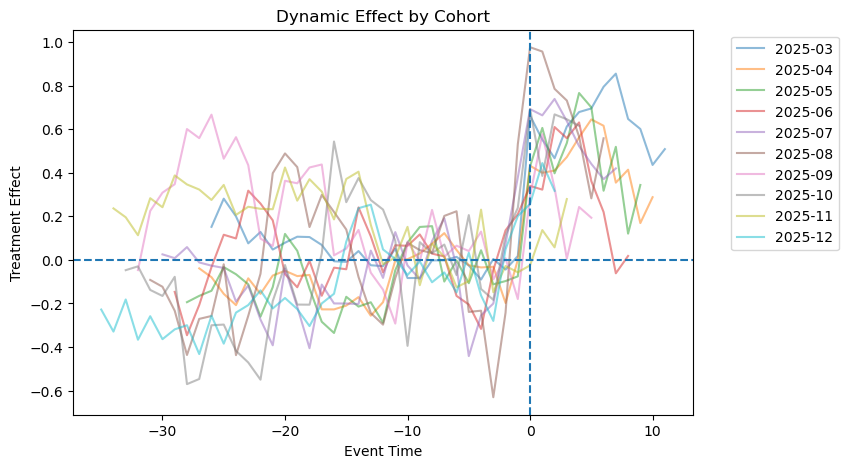


===== ATT BY COHORT =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 0.6260 0.0361 17.3465   0.0000  0.5553   0.6967         12
1  2025-04 0.4331 0.0422 10.2731   0.0000  0.3505   0.5158         11
2  2025-05 0.4739 0.0609  7.7756   0.0000  0.3544   0.5933         10
3  2025-06 0.3334 0.0821  4.0605   0.0000  0.1725   0.4944          9
4  2025-07 0.5609 0.0495 11.3272   0.0000  0.4639   0.6580          8
5  2025-08 0.6941 0.0929  7.4679   0.0000  0.5119   0.8762          7
6  2025-09 0.2739 0.0763  3.5884   0.0003  0.1243   0.4235          6
7  2025-10 0.6018 0.0555 10.8415   0.0000  0.4930   0.7106          5
8  2025-11 0.1122 0.0648  1.7318   0.0833 -0.0148   0.2392          4
9  2025-12 0.3396 0.0553  6.1421   0.0000  0.2313   0.4480          3
✅ Results saved to: /lakehouse/default/Files/output/inference/matching/summary_4_all


In [5]:
df_all = df[df["price"]== "all"] 
results_all = run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching/{match_method}_all")

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 8, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.1893        5.3730 -0.1837 0.2654 -0.6921   0.4889   
1          -34        5.5685        5.6026 -0.0340 0.2139 -0.1591   0.8736   
2          -33        5.6504        5.5990  0.0514 0.2018  0.2545   0.7991   
3          -32        5.4765        5.5285 -0.0519 0.1888 -0.2751   0.7833   
4          -31        5.2005        5.1812  0.0194 0.1775  0.1090   0.9132   
5          -30        4.9566        4.9724 -0.0158 0.1618 -0.0976   0.9222   
6          -29        5.0454        5.0154  0.0300 0.1526  0.1968   0.8440   
7          -28        4.9649        5.0341 -0.0691 0.1296 -0.5333   0.5938   
8          -27        5.1166        5.1551 -0.0386 0.1078 -0.3575   0.7207   
9          -26        5.6511        5.5735  0.0776 0.0887  0.8741   0.3821   
10         -25        5.7639        5.6228  0.1411 0.0922  1.5297   0.1261   
11         -

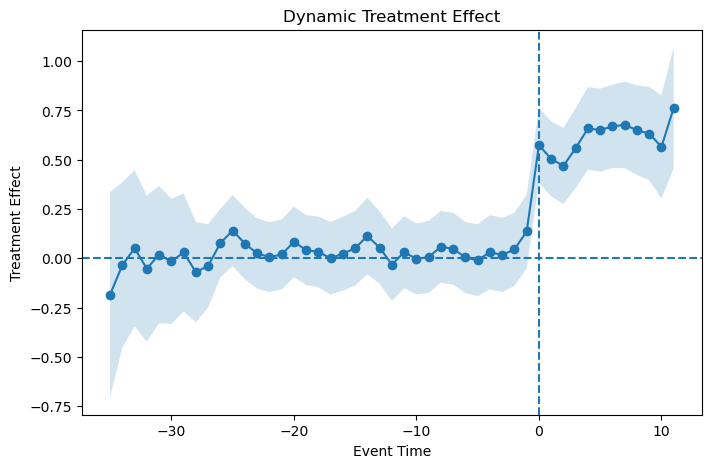


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.028133286138535125, 't_stat': 2.258338594122594, 'p_value': 0.04522369282399599}

===== OVERALL ATT =====
{'ATT': 0.6143745715669892, 'SE': 0.02374801573543753, 't_stat': 25.870564446788716, 'p_value': 0.0, 'CI_low': 0.5678284607255316, 'CI_high': 0.6609206824084467, 'n_periods': 12}

===== COHORT DYNAMIC EFFECT =====


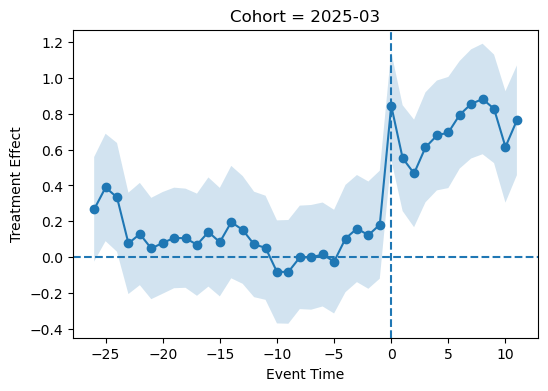

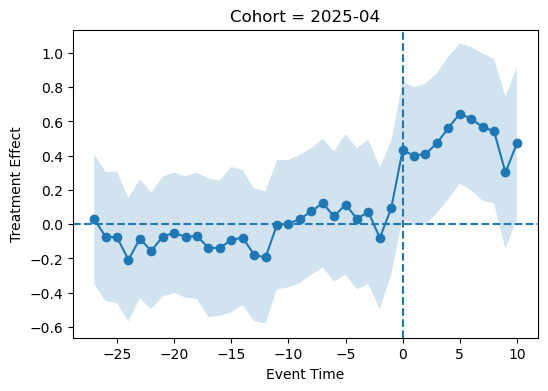

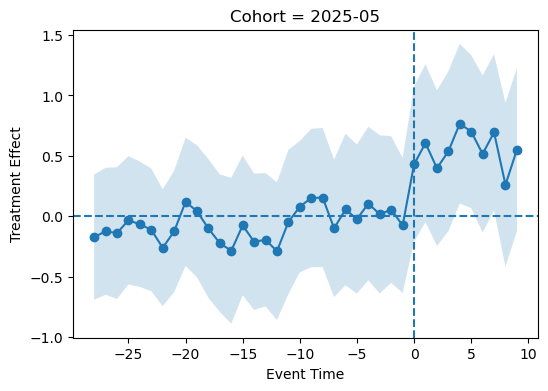

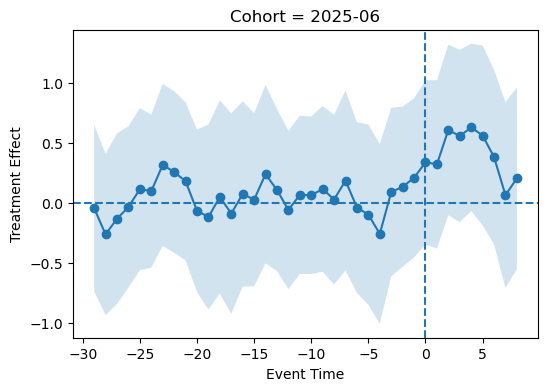

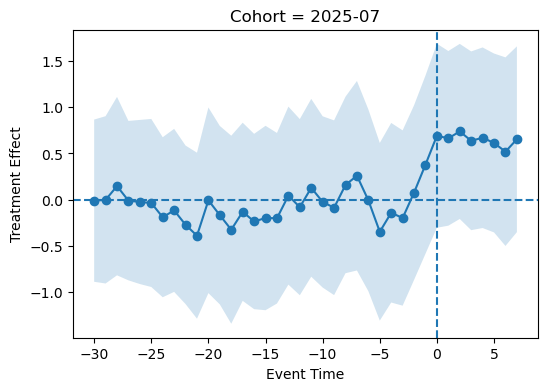

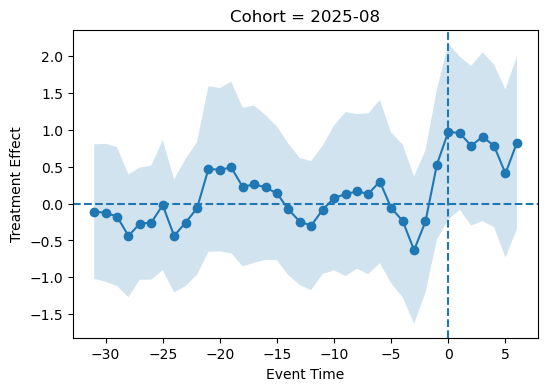

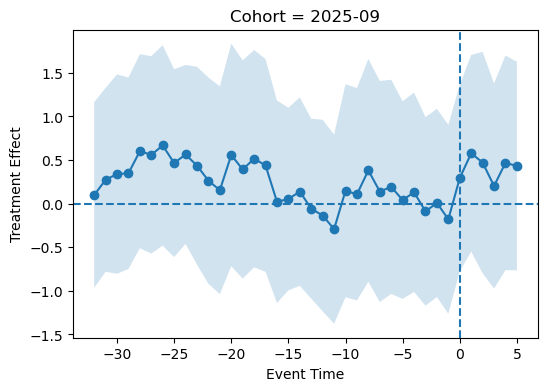

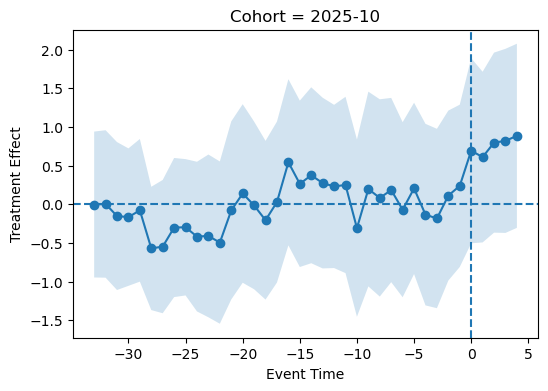

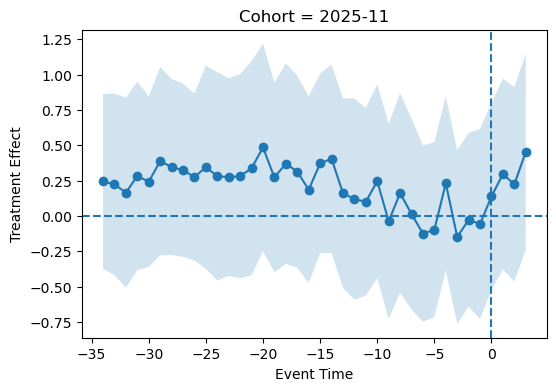

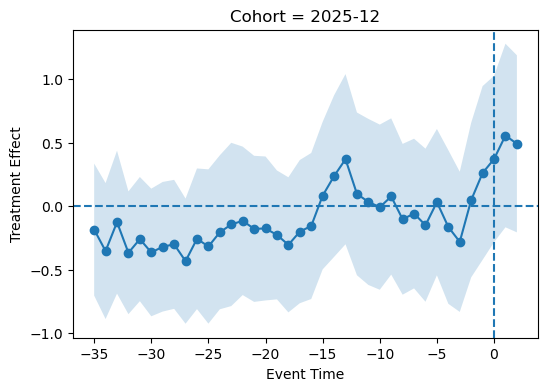

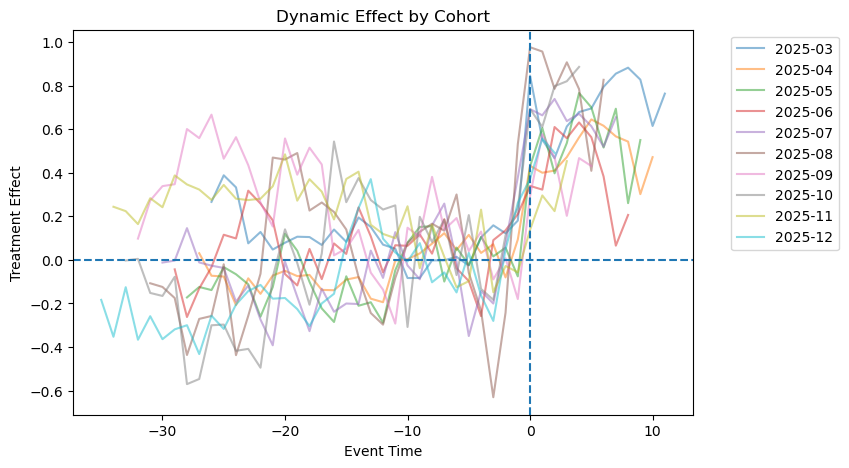


===== ATT BY COHORT =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 0.7160 0.0386 18.5508   0.0000  0.6403   0.7916         12
1  2025-04 0.4930 0.0313 15.7560   0.0000  0.4316   0.5543         11
2  2025-05 0.5458 0.0490 11.1437   0.0000  0.4498   0.6418         10
3  2025-06 0.4090 0.0654  6.2515   0.0000  0.2808   0.5373          9
4  2025-07 0.6489 0.0227 28.5925   0.0000  0.6045   0.6934          8
5  2025-08 0.8067 0.0725 11.1213   0.0000  0.6646   0.9489          7
6  2025-09 0.4071 0.0554  7.3470   0.0000  0.2985   0.5157          6
7  2025-10 0.7617 0.0489 15.5895   0.0000  0.6659   0.8575          5
8  2025-11 0.2780 0.0668  4.1639   0.0000  0.1471   0.4088          4
9  2025-12 0.4736 0.0543  8.7210   0.0000  0.3672   0.5801          3
✅ Results saved to: /lakehouse/default/Files/output/inference/matching/summary_4_low


In [6]:
df_low = df[df["price"]== "low"] 
results_low = run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching/{match_method}_low")

In [8]:
# Change here !!!
match_method = "summary_season2"
# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2


# 1. Read data
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching/{match_method}/matches")
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")

# 2. create matched panel
df = build_matched_panel(matches, month_result)

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 10, Finished, Available, Finished, False)

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 11, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se   t_stat  p_value  \
0          -35        4.7303        4.8239 -0.0936 0.2364  -0.3958   0.6922   
1          -34        4.7393        4.9051 -0.1658 0.1652  -1.0033   0.3157   
2          -33        4.7656        4.9499 -0.1843 0.1584  -1.1635   0.2446   
3          -32        4.8386        5.1262 -0.2876 0.1875  -1.5337   0.1251   
4          -31        4.7643        4.8285 -0.0642 0.2462  -0.2608   0.7942   
5          -30        4.7971        4.8088 -0.0117 0.2503  -0.0466   0.9628   
6          -29        4.4810        4.8200 -0.3390 0.1827  -1.8554   0.0635   
7          -28        4.4976        4.7966 -0.2990 0.1497  -1.9971   0.0458   
8          -27        4.4471        4.7827 -0.3356 0.1099  -3.0522   0.0023   
9          -26        4.5971        5.0716 -0.4745 0.0791  -6.0010   0.0000   
10         -25        4.7440        5.2239 -0.4799 0.0834  -5.7549   0.0000   


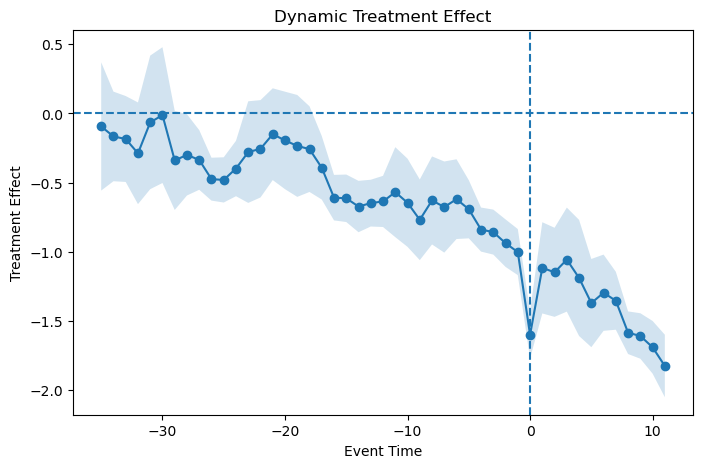


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': -0.7388484235876381, 't_stat': -18.33213957596656, 'p_value': 1.3573035325231055e-09}

===== OVERALL ATT =====
{'ATT': -1.402435650994021, 'SE': 0.07295829835626685, 't_stat': -19.22242818967223, 'p_value': 0.0, 'CI_low': -1.545433915772304, 'CI_high': -1.259437386215738, 'n_periods': 12}

===== COHORT DYNAMIC EFFECT =====


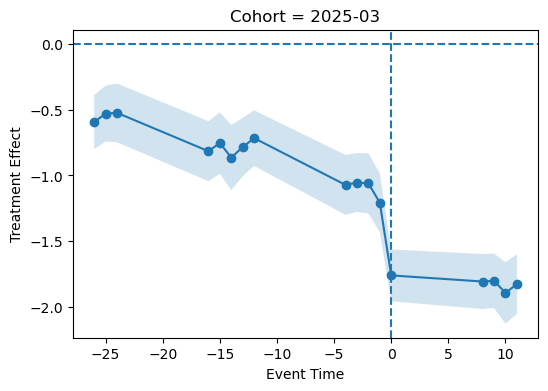

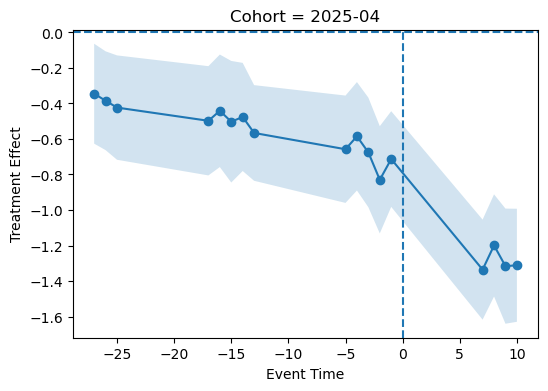

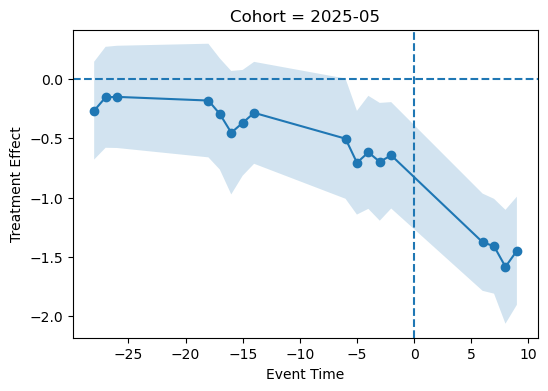

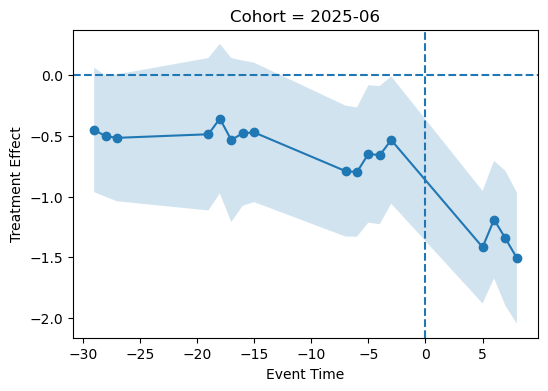

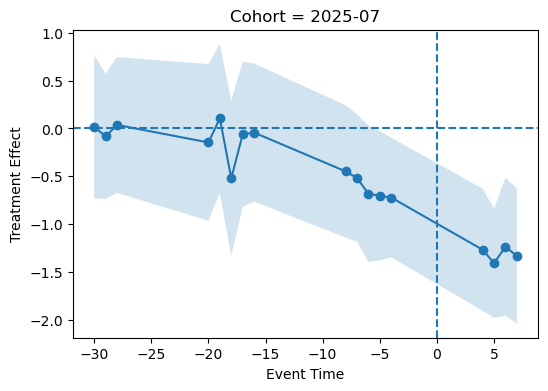

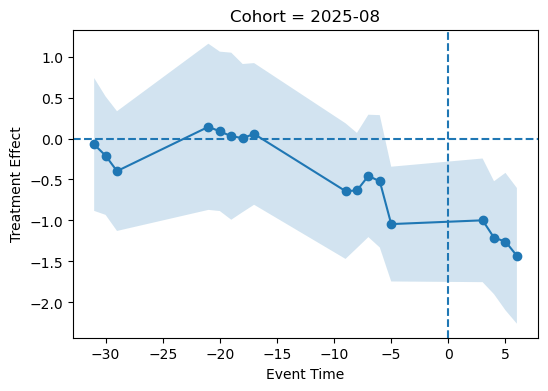

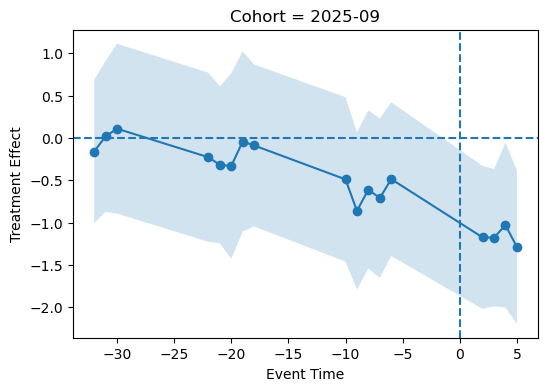

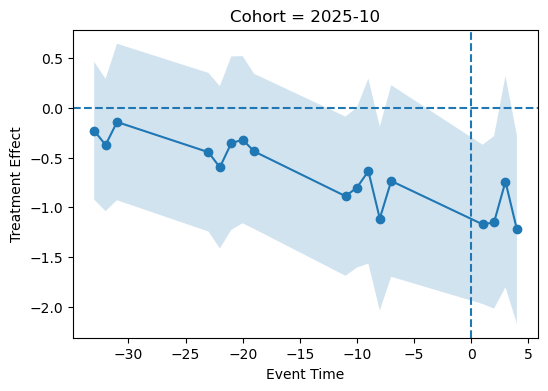

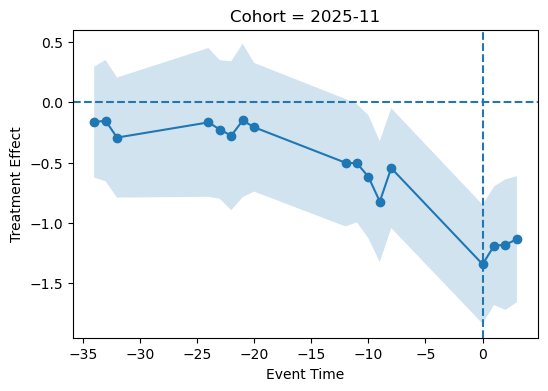

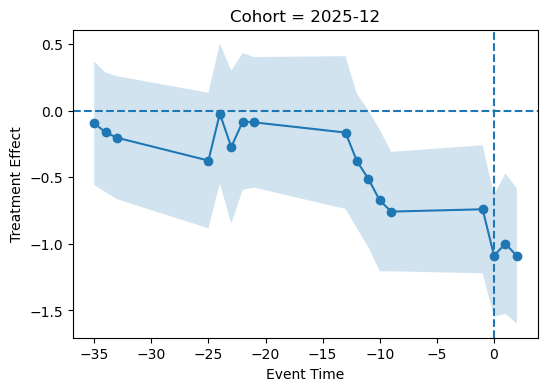

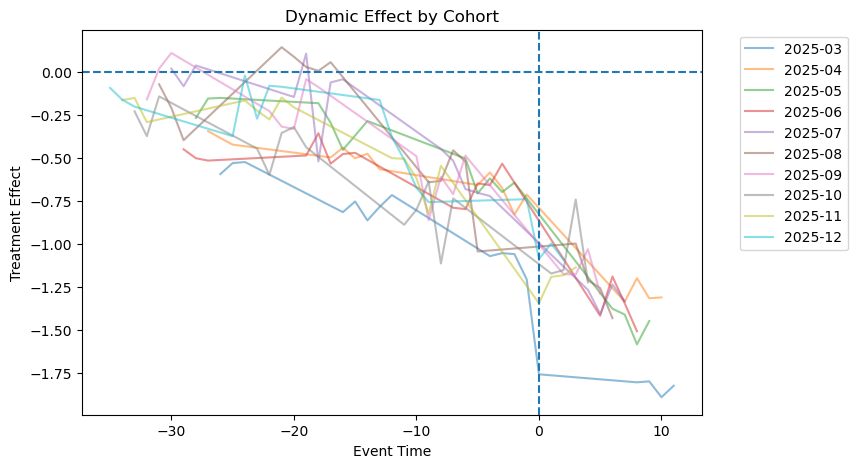


===== ATT BY COHORT =====
    cohort     ATT     SE   t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 -1.8155 0.0218 -83.3011   0.0000 -1.8582  -1.7728          5
1  2025-04 -1.2905 0.0308 -41.8640   0.0000 -1.3510  -1.2301          4
2  2025-05 -1.4551 0.0454 -32.0347   0.0000 -1.5441  -1.3660          4
3  2025-06 -1.3652 0.0673 -20.3001   0.0000 -1.4970  -1.2334          4
4  2025-07 -1.3110 0.0381 -34.4140   0.0000 -1.3857  -1.2364          4
5  2025-08 -1.2245 0.0892 -13.7323   0.0000 -1.3993  -1.0498          4
6  2025-09 -1.1688 0.0531 -22.0112   0.0000 -1.2728  -1.0647          4
7  2025-10 -1.0727 0.1111  -9.6536   0.0000 -1.2905  -0.8549          4
8  2025-11 -1.2140 0.0453 -26.8260   0.0000 -1.3027  -1.1253          4
9  2025-12 -1.0593 0.0306 -34.5894   0.0000 -1.1194  -0.9993          3
✅ Results saved to: /lakehouse/default/Files/output/inference/matching/summary_season2_high


In [9]:
df_high = df[df["price"]== "high"] 
run_full_analysis(df_high)
save_results(results_high, f"/lakehouse/default/Files/output/inference/matching/{match_method}_high")

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 12, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.4359        5.5930 -0.1571 0.2692 -0.5834   0.5596   
1          -34        5.8549        5.8333  0.0216 0.2146  0.1007   0.9198   
2          -33        5.9161        5.8447  0.0713 0.2014  0.3543   0.7231   
3          -32        5.6449        5.7089 -0.0640 0.1905 -0.3359   0.7370   
4          -31        5.3000        5.2571  0.0429 0.1784  0.2406   0.8098   
5          -30        5.0478        4.9856  0.0623 0.1631  0.3818   0.7026   
6          -29        5.1316        5.0267  0.1049 0.1531  0.6852   0.4932   
7          -28        5.0651        5.0495  0.0156 0.1299  0.1202   0.9044   
8          -27        5.2364        5.1757  0.0607 0.1079  0.5629   0.5735   
9          -26        5.7963        5.6947  0.1016 0.0889  1.1433   0.2529   
10         -25        5.9034        5.8076  0.0959 0.0924  1.0378   0.2993   
11         -

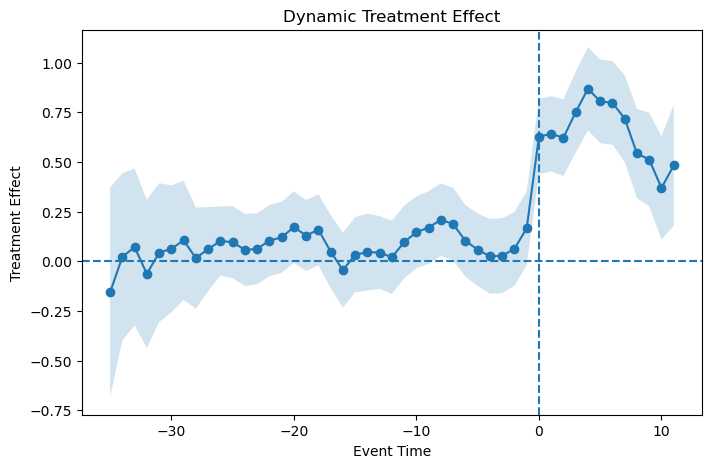


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.10564233904851765, 't_stat': 5.384000342507702, 'p_value': 0.0002219981829679024}

===== OVERALL ATT =====
{'ATT': 0.6443385696006877, 'SE': 0.04321735508874725, 't_stat': 14.909255049910673, 'p_value': 0.0, 'CI_low': 0.559632553626743, 'CI_high': 0.7290445855746324, 'n_periods': 12}

===== COHORT DYNAMIC EFFECT =====


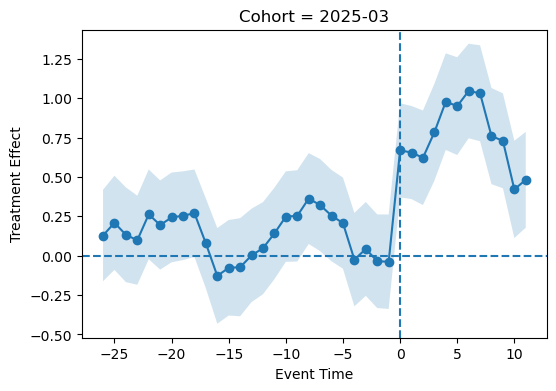

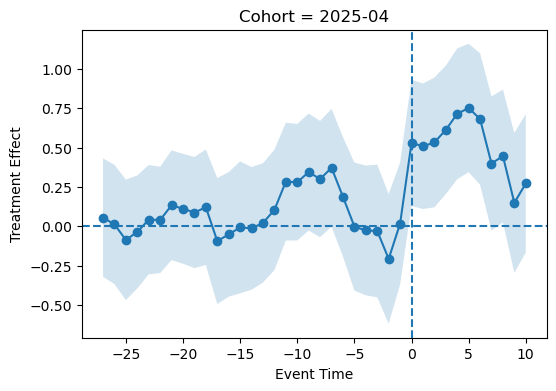

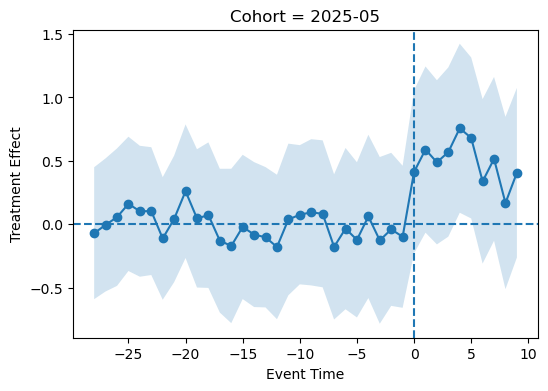

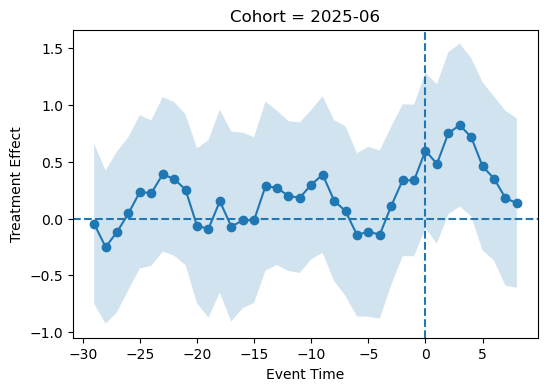

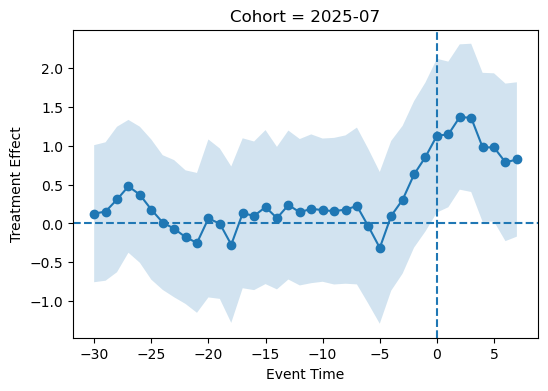

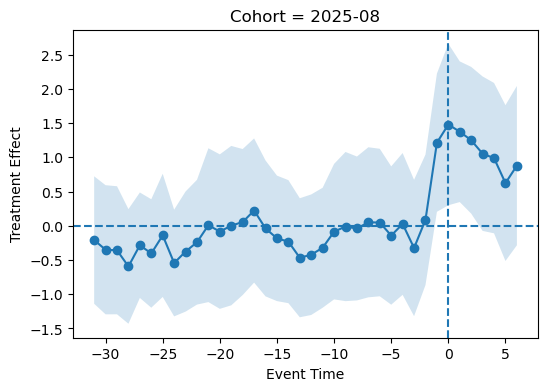

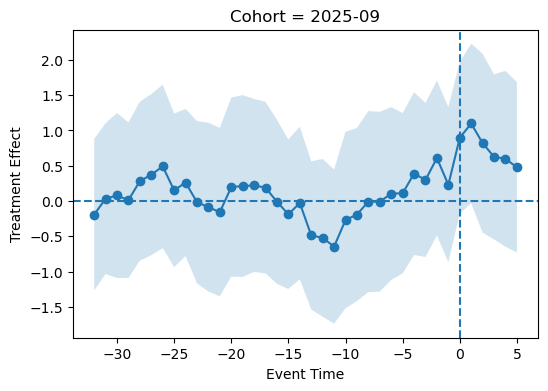

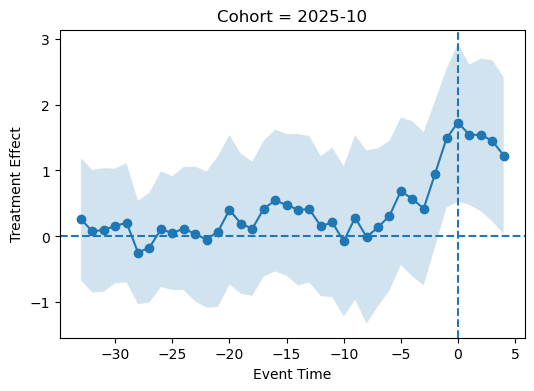

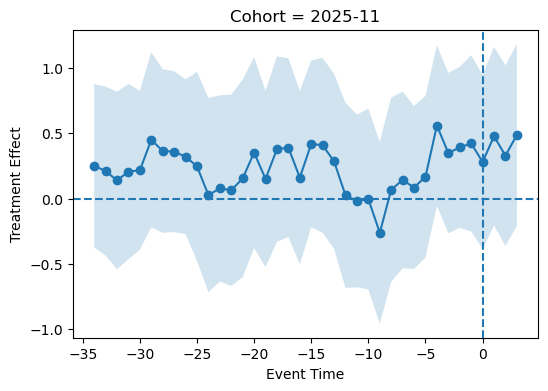

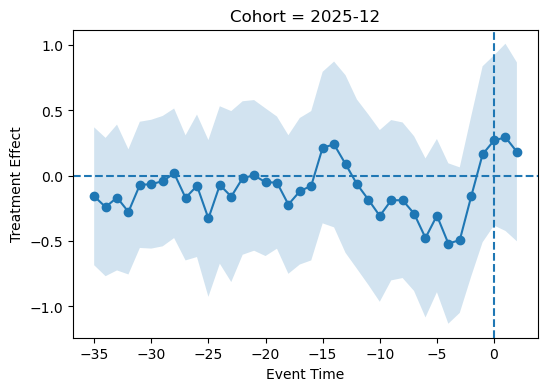

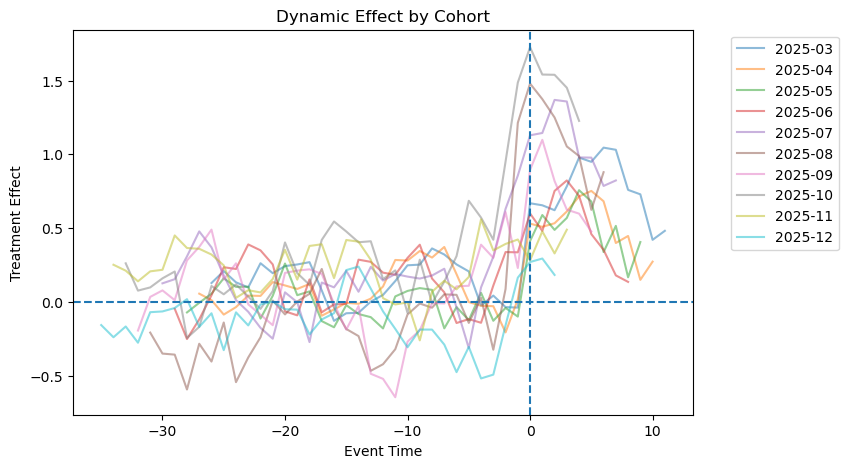


===== ATT BY COHORT =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 0.7602 0.0597 12.7275   0.0000  0.6431   0.8773         12
1  2025-04 0.5093 0.0559  9.1032   0.0000  0.3996   0.6190         11
2  2025-05 0.4921 0.0542  9.0717   0.0000  0.3858   0.5984         10
3  2025-06 0.5001 0.0820  6.0971   0.0000  0.3394   0.6609          9
4  2025-07 1.0709 0.0779 13.7440   0.0000  0.9182   1.2236          8
5  2025-08 1.0928 0.1125  9.7122   0.0000  0.8722   1.3133          7
6  2025-09 0.7521 0.0931  8.0764   0.0000  0.5696   0.9346          6
7  2025-10 1.4969 0.0810 18.4771   0.0000  1.3381   1.6557          5
8  2025-11 0.3943 0.0526  7.4979   0.0000  0.2912   0.4974          4
9  2025-12 0.2489 0.0338  7.3674   0.0000  0.1827   0.3152          3
✅ Results saved to: /lakehouse/default/Files/output/inference/matching/summary_season2_all


In [10]:
df_all = df[df["price"]== "all"] 
run_full_analysis(df_all)
save_results(results_all, f"/lakehouse/default/Files/output/inference/matching/{match_method}_all")

StatementMeta(, 3c2ad243-190f-4644-8002-4670a53ce5bc, 13, Finished, Available, Finished, False)

===== OVERALL EFFECT =====

Overall dynamic effect:
    event_time  mean_treated  mean_control  effect     se  t_stat  p_value  \
0          -35        5.1893        5.3093 -0.1200 0.2642 -0.4541   0.6498   
1          -34        5.5685        5.5484  0.0201 0.2136  0.0941   0.9250   
2          -33        5.6504        5.5571  0.0933 0.2011  0.4640   0.6427   
3          -32        5.4765        5.5043 -0.0277 0.1884 -0.1473   0.8829   
4          -31        5.2005        5.1536  0.0469 0.1772  0.2647   0.7912   
5          -30        4.9566        4.8928  0.0638 0.1614  0.3949   0.6929   
6          -29        5.0454        4.9115  0.1340 0.1525  0.8785   0.3797   
7          -28        4.9649        4.9206  0.0444 0.1295  0.3427   0.7318   
8          -27        5.1166        5.0129  0.1037 0.1074  0.9650   0.3345   
9          -26        5.6511        5.5008  0.1503 0.0886  1.6974   0.0896   
10         -25        5.7639        5.6062  0.1577 0.0922  1.7096   0.0873   
11         -

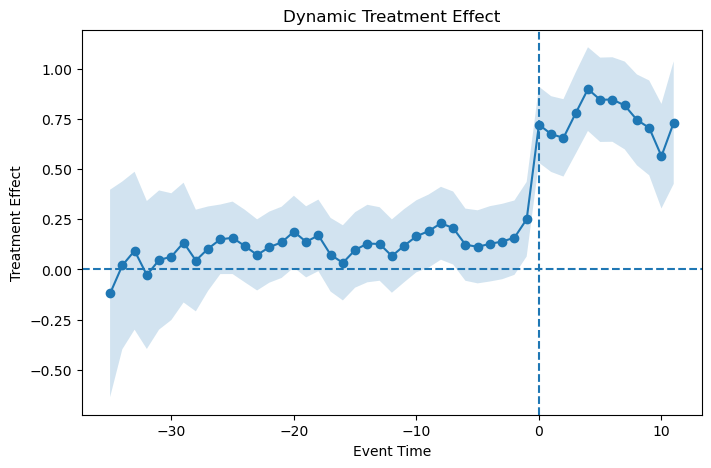


===== PRE-TREND TEST =====
{'pre_start': -12, 'pre_end': -1, 'n_periods': 12, 'mean_pre_effect': 0.15760126000665564, 't_stat': 10.16065896183244, 'p_value': 6.303081964294828e-07}

===== OVERALL ATT =====
{'ATT': 0.7498648184323772, 'SE': 0.02730368081336075, 't_stat': 27.463872858689413, 'p_value': 0.0, 'CI_low': 0.6963496040381901, 'CI_high': 0.8033800328265642, 'n_periods': 12}

===== COHORT DYNAMIC EFFECT =====


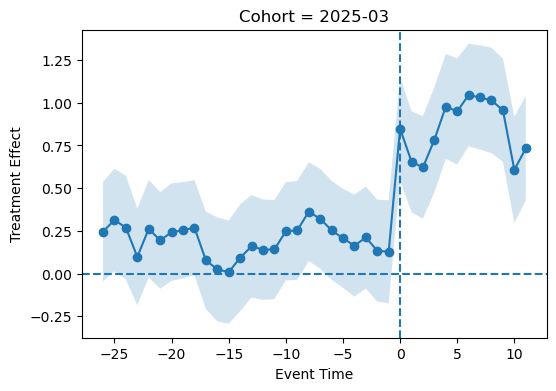

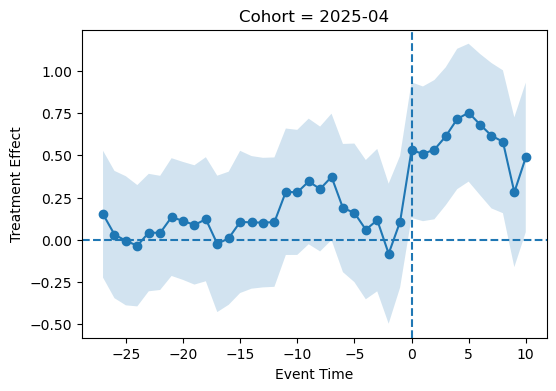

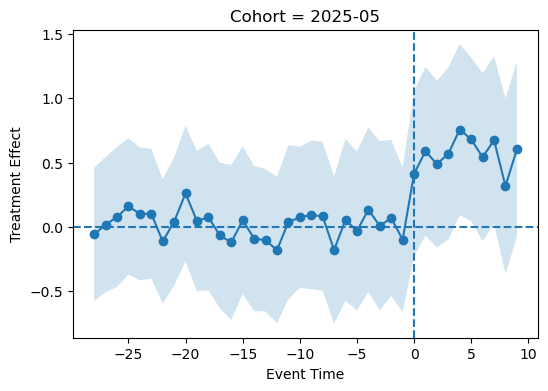

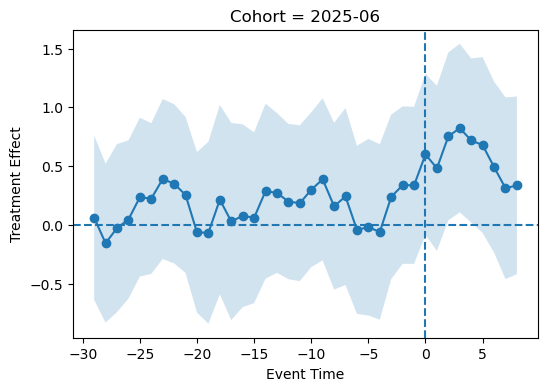

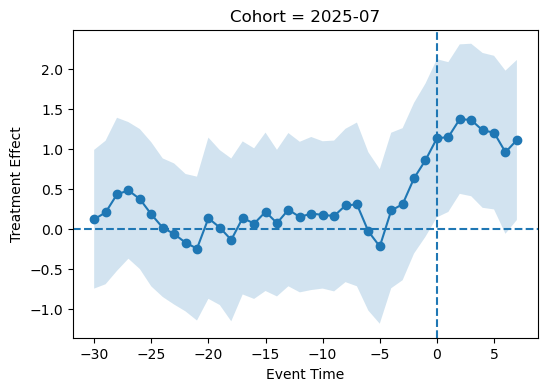

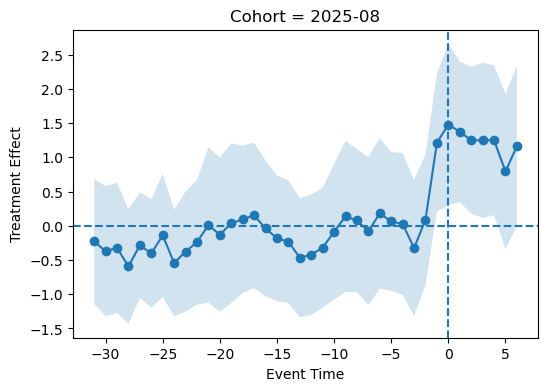

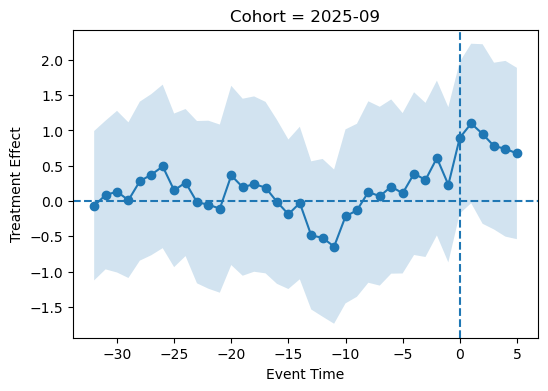

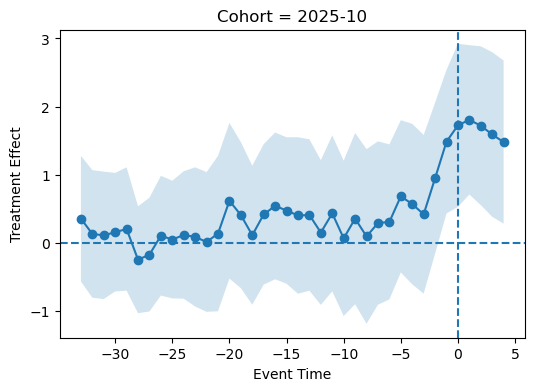

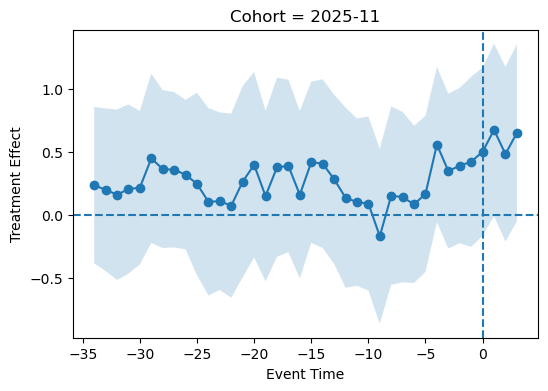

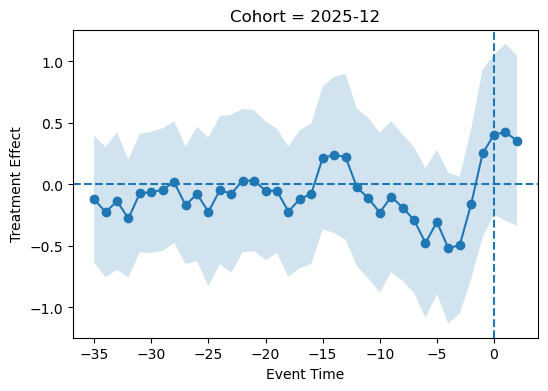

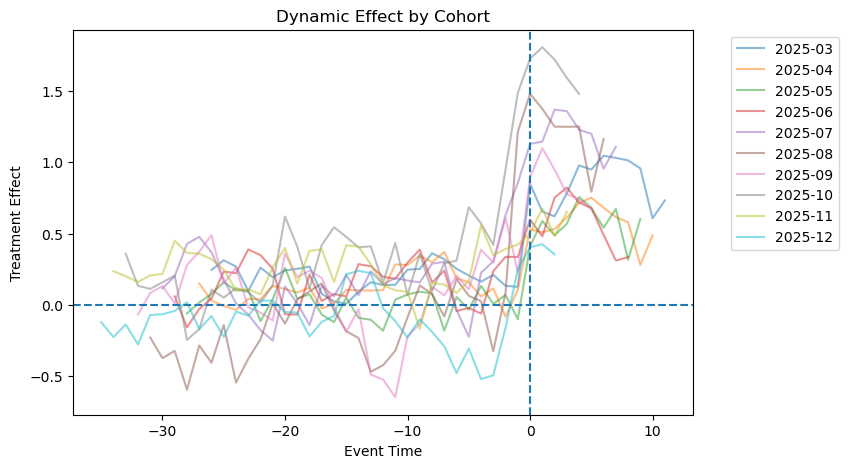


===== ATT BY COHORT =====
    cohort    ATT     SE  t_stat  p_value  CI_low  CI_high  n_periods
0  2025-03 0.8519 0.0479 17.7882   0.0000  0.7580   0.9457         12
1  2025-04 0.5726 0.0390 14.6757   0.0000  0.4962   0.6491         11
2  2025-05 0.5632 0.0415 13.5798   0.0000  0.4820   0.6445         10
3  2025-06 0.5768 0.0609  9.4677   0.0000  0.4574   0.6962          9
4  2025-07 1.1867 0.0481 24.6860   0.0000  1.0924   1.2809          8
5  2025-08 1.2230 0.0815 15.0132   0.0000  1.0633   1.3826          7
6  2025-09 0.8554 0.0638 13.4150   0.0000  0.7305   0.9804          6
7  2025-10 1.6647 0.0577 28.8676   0.0000  1.5517   1.7777          5
8  2025-11 0.5789 0.0498 11.6227   0.0000  0.4813   0.6765          4
9  2025-12 0.3952 0.0209 18.8947   0.0000  0.3542   0.4362          3
✅ Results saved to: /lakehouse/default/Files/output/inference/matching/summary_season2_low


In [11]:
df_low = df[df["price"]== "low"] 
run_full_analysis(df_low)
save_results(results_low, f"/lakehouse/default/Files/output/inference/matching/{match_method}_low")